# NSCLC Cell Category Spatial Survival Analysis

Figure 6-style spatial interaction and survival analysis at the four-category level: tumor, immune, vessel, and CAF.

In [8]:
from pathlib import Path
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and cwd.parent.name == "multiTAP":
    PROJECT_ROOT = cwd.parents[1]
elif (cwd / "multiTAP" / "notebooks").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = Path("/project/Xie_Lab/zgu/xiao_multiplex")

NOTEBOOK_DIR = PROJECT_ROOT / "multiTAP" / "notebooks"
TUTORIAL_DIR = PROJECT_ROOT / "multiTAP" / "nsclc_tutorial"
WORK_DIR = PROJECT_ROOT / "nsclc_multiTAP_work"
OUTPUT_DIR = WORK_DIR / "05-08-26_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ACCUMUL_TYPE = "sum"
K_NEIGHBORS = 15
CATEGORY_COLS = [
    "cell_category_tumor",
    "cell_category_immune",
    "cell_category_vessel",
    "cell_category_CAF",
]
CATEGORY_LABELS = ["tumor", "immune", "vessel", "CAF"]

CATEGORY_PATH = OUTPUT_DIR / f"cell_categories_accuml_{ACCUMUL_TYPE}.csv"
SPATIAL_PATH = OUTPUT_DIR / f"cell_category_spatial_kneighbor{K_NEIGHBORS}_{ACCUMUL_TYPE}.csv"
CLINICAL_PATH = WORK_DIR / "clinical_data_ROI.csv"

FDR_ALPHA = 0.05
MINIMUM_PT_THRESH = 100
MINIMUM_GROUP_SIZE = 10
MINIMUM_GROUP_EVENTS = 1

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"CATEGORY_PATH = {CATEGORY_PATH}")
print(f"SPATIAL_PATH = {SPATIAL_PATH}")

PROJECT_ROOT = /project/Xie_Lab/zgu/xiao_multiplex
OUTPUT_DIR = /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-08-26_results
CATEGORY_PATH = /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-08-26_results/cell_categories_accuml_sum.csv
SPATIAL_PATH = /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-08-26_results/cell_category_spatial_kneighbor15_sum.csv


## Generate or Load Category-Level Spatial Inputs

In [9]:
python_exe = Path(sys.executable)
if not CATEGORY_PATH.exists():
    subprocess.run([
        str(python_exe),
        str(TUTORIAL_DIR / "cell_category_from_mapped_cell_types.py"),
        "--accuml-type", ACCUMUL_TYPE,
        "--output-dir", str(OUTPUT_DIR),
    ], check=True)

if not SPATIAL_PATH.exists():
    subprocess.run([
        str(python_exe),
        str(TUTORIAL_DIR / "spatial_from_cell_categories.py"),
        "--accuml-type", ACCUMUL_TYPE,
        "--k-neighbors", str(K_NEIGHBORS),
        "--output-dir", str(OUTPUT_DIR),
    ], check=True)

category_df = pd.read_csv(CATEGORY_PATH)
print("cell category table:", category_df.shape)
display(category_df["cell_category"].value_counts(dropna=False).to_frame("n_cells"))
print("unique ROIs:", category_df["roi_id"].nunique())
print("unique patients:", category_df["pt_id"].nunique())

cell category table: (3935322, 6)


,n_cells
NaN,2099190
tumor,1040149
CAF,559035
immune,198113
vessel,38835


unique ROIs: 1952
unique patients: 1067


## Figure 6B Equivalent: Mean Category Interaction Matrix

1952 ROIs identified
spatial table: (7808, 5)
# positive interactions 0
# negative interactions 16
# null interactions 0


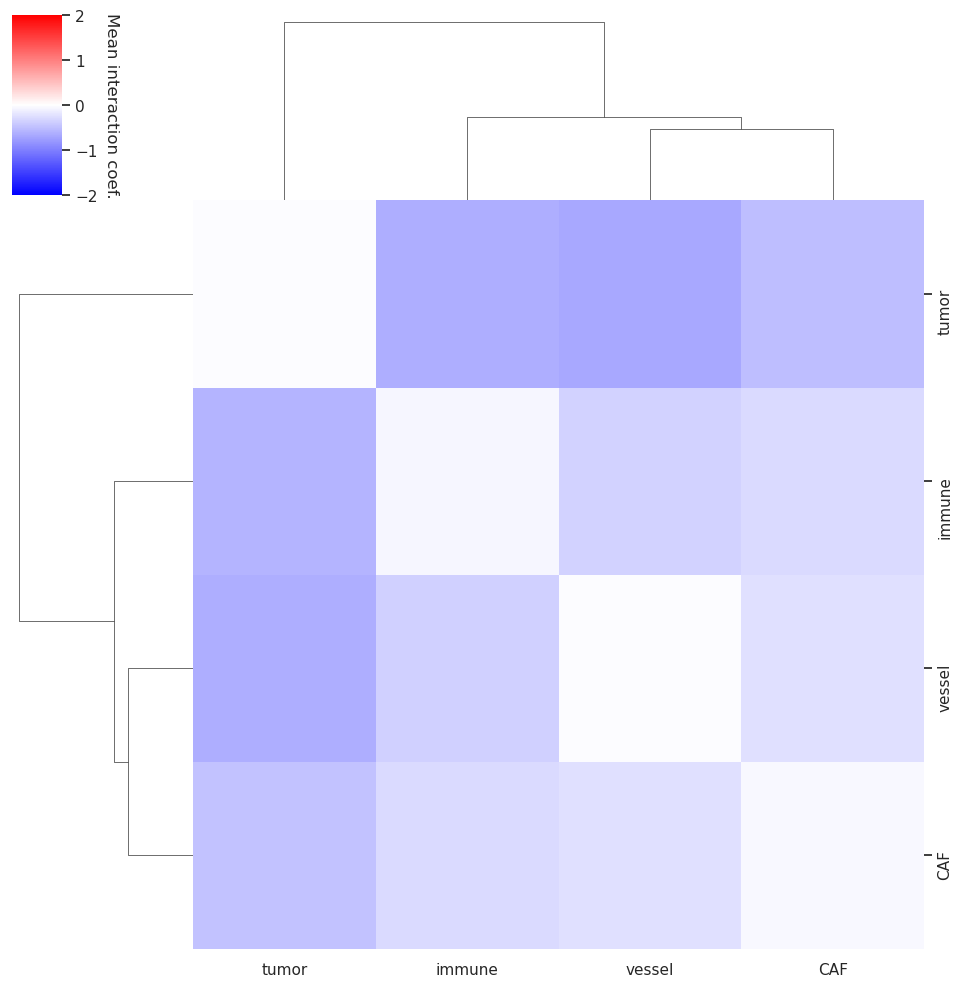

,cell_category_tumor,cell_category_immune,cell_category_vessel,cell_category_CAF
cell_category,,,,
cell_category_tumor,-0.028526,-0.626317,-0.683933,-0.507021
cell_category_immune,-0.585287,-0.065700,-0.358744,-0.285031
cell_category_vessel,-0.634376,-0.360599,-0.017693,-0.239804
cell_category_CAF,-0.482580,-0.291828,-0.244029,-0.055846


In [10]:
spatial_pt_df = pd.read_csv(SPATIAL_PATH, index_col=0)
print(f"{spatial_pt_df['roi_id'].nunique()} ROIs identified")
print("spatial table:", spatial_pt_df.shape)

spatial_pt_df = spatial_pt_df.reset_index(names="cell_category")
spatial_pt_df = spatial_pt_df.replace(0, np.nan)

grouped_spatial = spatial_pt_df.groupby("cell_category")[CATEGORY_COLS].mean(numeric_only=True)
grouped_spatial = grouped_spatial.reindex(index=CATEGORY_COLS, columns=CATEGORY_COLS).fillna(0)

spatial_vals = grouped_spatial.values
print("# positive interactions", int(np.sum(spatial_vals > 0)))
print("# negative interactions", int(np.sum(spatial_vals < 0)))
print("# null interactions", int(np.sum(spatial_vals == 0)))

clustergrid = sns.clustermap(
    grouped_spatial,
    center=np.log10(1 + 1e-6),
    cmap="bwr",
    vmin=-2,
    vmax=2,
    xticklabels=CATEGORY_LABELS,
    yticklabels=CATEGORY_LABELS,
)
clustergrid.ax_heatmap.set_ylabel("")
clustergrid.cax.set_ylabel("Mean interaction coef.", rotation=270, labelpad=15)
clustergrid.savefig(OUTPUT_DIR / "cell_category_figure6b_clustermap.pdf", bbox_inches="tight")
plt.show()

grouped_spatial.to_csv(OUTPUT_DIR / "cell_category_mean_interaction_matrix.csv")
display(grouped_spatial)

## Figure 6C Equivalent: Survival Screen

In [11]:
def flatten_interaction_matrix(df: pd.DataFrame) -> pd.DataFrame:
    if df.shape[0] != df.shape[1]:
        raise ValueError("Input DataFrame must be square.")
    if not df.columns.equals(df.index):
        raise ValueError("DataFrame must have matching row and column labels.")
    colnames = [f"{row}_to_{col}" for row in df.index for col in df.columns]
    return pd.DataFrame([df.values.flatten()], columns=colnames)


def extract_roi_id(roi_id):
    try:
        split = roi_id.split("_")
        if roi_id.startswith("178_A") or roi_id.startswith("178_C"):
            return f"{split[0]}_{split[2]}{split[3]},{split[4]}"
        if roi_id.startswith("178_B"):
            return f"{split[0]}_{split[3]}{split[4]},{split[5]}"
        return f"{split[0]}_{split[2]},{split[3]}"
    except IndexError:
        return None


flat_marker_roi_list = []
for roi_id in np.unique(spatial_pt_df["roi_id"]):
    try:
        one_spatial_mat = spatial_pt_df.loc[spatial_pt_df["roi_id"] == roi_id]
        one_spatial_mat = one_spatial_mat.set_index("cell_category")[CATEGORY_COLS]
        one_spatial_mat = one_spatial_mat.reindex(index=CATEGORY_COLS, columns=CATEGORY_COLS)
        flat_edge_perc_remapped = flatten_interaction_matrix(one_spatial_mat)
        flat_edge_perc_remapped["ROI_ID"] = roi_id
        flat_marker_roi_list.append(flat_edge_perc_remapped)
    except Exception as exc:
        print(f"ROI {roi_id} not processed due to error {exc}")

combined_df = pd.concat(flat_marker_roi_list, axis=0, ignore_index=True)
combined_df["roi_mappable"] = combined_df["ROI_ID"].str.replace("NSCLC_ALL_", "", regex=False).apply(extract_roi_id)
print("flattened ROI feature table:", combined_df.shape)
display(combined_df.head())

flattened ROI feature table: (1952, 18)


,cell_category_tumor_to_cell_category_tumor,cell_category_tumor_to_cell_category_immune,cell_category_tumor_to_cell_category_vessel,cell_category_tumor_to_cell_category_CAF,cell_category_immune_to_cell_category_tumor,cell_category_immune_to_cell_category_immune,cell_category_immune_to_cell_category_vessel,cell_category_immune_to_cell_category_CAF,cell_category_vessel_to_cell_category_tumor,cell_category_vessel_to_cell_category_immune,cell_category_vessel_to_cell_category_vessel,cell_category_vessel_to_cell_category_CAF,cell_category_CAF_to_cell_category_tumor,cell_category_CAF_to_cell_category_immune,cell_category_CAF_to_cell_category_vessel,cell_category_CAF_to_cell_category_CAF,ROI_ID,roi_mappable
0,-0.064383,-0.686800,-0.549764,-0.462420,-0.677040,-0.042025,NaN,-0.103719,-0.487616,NaN,NaN,-0.210721,-0.470635,-0.146415,-0.240684,-0.019412,NSCLC_ALL_175_A_A1_1,"175_A1,1"
1,NaN,NaN,NaN,NaN,NaN,-0.386013,-0.328020,-0.337279,NaN,-0.275314,-0.504566,-0.333022,NaN,-0.356584,-0.366445,-0.064758,NSCLC_ALL_175_A_A1_10,"175_A1,10"
2,-0.073733,-0.402949,-0.621997,-0.511743,-0.369853,-0.474043,-0.342485,-0.383150,-0.581464,-0.391703,0.062056,-0.042051,-0.444743,-0.393701,-0.053695,0.025228,NSCLC_ALL_175_A_A1_11,"175_A1,11"
3,0.050238,-0.919818,-0.887460,-0.993346,-0.637014,0.444450,-0.083318,0.028608,-0.626933,-0.106799,0.293502,0.009076,-0.650697,0.034437,0.074446,0.349428,NSCLC_ALL_175_A_A1_12,"175_A1,12"
4,0.073487,-0.906277,NaN,-0.744431,-0.861980,-0.014410,-0.027993,-0.053787,-1.616852,-0.152932,NaN,-0.010550,-0.712298,-0.070159,-0.029855,0.099845,NSCLC_ALL_175_A_A1_13,"175_A1,13"


In [12]:
pt_clinical_data = pd.read_csv(CLINICAL_PATH)
print(f"{pt_clinical_data['Patient_ID'].nunique()} unique subjects before filtering")

pt_clinical_data = pt_clinical_data.loc[pt_clinical_data["Patient_ID"] != "Control"].copy()
pt_clinical_data = pt_clinical_data.loc[~pt_clinical_data["NeoAdj"].isna()].copy()
pt_clinical_data = pt_clinical_data.loc[pt_clinical_data["NeoAdj"] != "NeoAdjuvantTherapy"].reset_index(drop=True)
pt_clinical_data = pt_clinical_data[["RoiID", "Patient_ID", "OS", "DFS", "Ev.O", "DX.name"]]
pt_clinical_data = pt_clinical_data.drop_duplicates(keep="first").reset_index(drop=True)
print(f"{pt_clinical_data['Patient_ID'].nunique()} unique patients after clinical filtering")

spatial_clinical_merged = combined_df.merge(pt_clinical_data, how="inner", left_on="roi_mappable", right_on="RoiID")
spatial_clinical_merged = spatial_clinical_merged.dropna(subset=["OS", "Ev.O"]).reset_index(drop=True)
print("unique patients after ROI/survival merge:", spatial_clinical_merged["Patient_ID"].nunique())
print("unique ROIs after ROI/survival merge:", spatial_clinical_merged["roi_mappable"].nunique())

feature_cols = [col for col in spatial_clinical_merged.columns if col.startswith("cell_category_")]
survival_df = spatial_clinical_merged[feature_cols + ["OS", "Ev.O", "Patient_ID", "DX.name"]].copy()

tumor_type_conflicts = survival_df.groupby("Patient_ID")["DX.name"].nunique(dropna=False)
tumor_type_conflicts = tumor_type_conflicts[tumor_type_conflicts > 1]
print(f"Patients with ROI-level tumor type conflicts: {len(tumor_type_conflicts)}")

survival_df = survival_df.groupby("Patient_ID").agg(
    {**{col: "mean" for col in feature_cols + ["OS", "Ev.O"]}, "DX.name": "first"}
).reset_index()
print("patient-level survival frame:", survival_df.shape)
display(survival_df.head())

1071 unique subjects before filtering
959 unique patients after clinical filtering
unique patients after ROI/survival merge: 953
unique ROIs after ROI/survival merge: 1757
Patients with ROI-level tumor type conflicts: 0
patient-level survival frame: (953, 20)


,Patient_ID,cell_category_tumor_to_cell_category_tumor,cell_category_tumor_to_cell_category_immune,cell_category_tumor_to_cell_category_vessel,cell_category_tumor_to_cell_category_CAF,cell_category_immune_to_cell_category_tumor,cell_category_immune_to_cell_category_immune,cell_category_immune_to_cell_category_vessel,cell_category_immune_to_cell_category_CAF,cell_category_vessel_to_cell_category_tumor,cell_category_vessel_to_cell_category_immune,cell_category_vessel_to_cell_category_vessel,cell_category_vessel_to_cell_category_CAF,cell_category_CAF_to_cell_category_tumor,cell_category_CAF_to_cell_category_immune,cell_category_CAF_to_cell_category_vessel,cell_category_CAF_to_cell_category_CAF,OS,Ev.O,DX.name
0,175_1,-0.056855,-0.709698,-0.638546,-0.473261,-0.666046,0.238954,-0.291430,-0.131453,-0.620636,-0.291430,NaN,-0.133194,-0.477819,-0.169149,-0.187766,-0.005864,254.0,1.0,Adenocarcinoma
1,175_10,0.173452,-0.419165,-0.489850,-0.619494,-0.297663,0.088554,-0.441557,-0.487212,-0.448319,-0.437170,0.020512,-0.440825,-0.645030,-0.479838,-0.431180,-0.115590,1134.0,1.0,Adenocarcinoma
2,175_100,0.001182,-0.616412,-1.005548,-0.639536,-0.542987,0.147070,-0.207941,-0.142745,-0.830865,-0.155454,0.666509,0.179948,-0.540289,-0.166269,0.153721,0.169059,490.0,1.0,Squamous cell carcinoma
3,175_101,-0.306186,-0.442615,-0.792693,-0.327018,-0.801636,-0.320542,-0.475179,-0.398898,-0.792693,-0.427209,-0.408805,-0.422996,-0.414168,-0.386369,-0.399122,-0.175660,1930.0,1.0,Squamous cell carcinoma
4,175_102,0.193725,-0.926437,-1.070127,-0.283700,-1.187871,-0.181558,-0.468081,-0.458318,-1.308677,-0.446246,-0.360905,-0.433903,-0.394539,-0.392652,-0.348551,-0.160290,794.0,1.0,Squamous cell carcinoma


In [13]:
results = []
skipped_features = []

for feature in feature_cols:
    km_cols = [feature, "OS", "Ev.O", "Patient_ID"]
    km_df = survival_df[km_cols].dropna(subset=[feature, "OS", "Ev.O"]).copy()
    n_available = km_df.shape[0]
    if n_available < MINIMUM_PT_THRESH:
        skipped_features.append({"feature": feature, "reason": "n_available", "n_available": n_available})
        continue

    median_feature = km_df[feature].median()
    km_df["exp_group"] = np.where(km_df[feature] > median_feature, "high", "low")
    low_df = km_df.loc[km_df["exp_group"] == "low"]
    high_df = km_df.loc[km_df["exp_group"] == "high"]
    n_low, n_high = low_df.shape[0], high_df.shape[0]
    events_low, events_high = low_df["Ev.O"].sum(), high_df["Ev.O"].sum()

    if min(n_low, n_high) < MINIMUM_GROUP_SIZE:
        skipped_features.append({"feature": feature, "reason": "n_per_group", "n_available": n_available, "n_low": n_low, "n_high": n_high})
        continue
    if min(events_low, events_high) < MINIMUM_GROUP_EVENTS:
        skipped_features.append({"feature": feature, "reason": "events_per_group", "n_available": n_available, "n_low": n_low, "n_high": n_high, "events_low": events_low, "events_high": events_high})
        continue

    logrank_res = logrank_test(
        low_df["OS"], high_df["OS"],
        event_observed_A=low_df["Ev.O"],
        event_observed_B=high_df["Ev.O"],
    )
    results.append({
        "feature": feature,
        "n_available": n_available,
        "n_low": n_low,
        "n_high": n_high,
        "events_low": events_low,
        "events_high": events_high,
        "median_feature": median_feature,
        "pval": logrank_res.p_value,
    })

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df["pval_adj_bh"] = multipletests(results_df["pval"], method="fdr_bh")[1]
    results_df[f"bh_significant_{FDR_ALPHA:g}"] = results_df["pval_adj_bh"] < FDR_ALPHA

skipped_features_df = pd.DataFrame(
    skipped_features,
    columns=["feature", "reason", "n_available", "n_low", "n_high", "events_low", "events_high"],
)
print(f"Features tested: {results_df.shape[0]}")
print(f"Features skipped: {skipped_features_df.shape[0]}")
if not skipped_features_df.empty:
    display(skipped_features_df["reason"].value_counts().to_frame("n_features"))
display(results_df.sort_values("pval") if not results_df.empty else results_df)

results_path = OUTPUT_DIR / "cell_category_spatial_survival_logrank_results.csv"
skipped_path = OUTPUT_DIR / "cell_category_spatial_survival_skipped_features.csv"
patient_path = OUTPUT_DIR / "cell_category_spatial_patient_level_features.csv"
results_df.sort_values("pval").to_csv(results_path, index=False)
skipped_features_df.to_csv(skipped_path, index=False)
survival_df.to_csv(patient_path, index=False)

print(f"Saved results to {results_path}")
print(f"Saved skipped features to {skipped_path}")
print(f"Saved patient-level features to {patient_path}")

Features tested: 16
Features skipped: 0


,feature,n_available,n_low,n_high,events_low,events_high,median_feature,pval,pval_adj_bh,bh_significant_0.05
2,cell_category_tumor_to_cell_category_vessel,834,417,417,282.0,300.0,-0.634791,0.013865,0.189151,False
14,cell_category_CAF_to_cell_category_vessel,912,456,456,323.0,310.0,-0.298157,0.030677,0.189151,False
12,cell_category_CAF_to_cell_category_tumor,943,472,471,315.0,337.0,-0.453998,0.035466,0.189151,False
8,cell_category_vessel_to_cell_category_tumor,830,415,415,284.0,298.0,-0.585110,0.052755,0.211019,False
11,cell_category_vessel_to_cell_category_CAF,911,456,455,322.0,310.0,-0.283148,0.079564,0.254605,False
4,cell_category_immune_to_cell_category_tumor,930,465,465,312.0,328.0,-0.553469,0.179425,0.454514,False
5,cell_category_immune_to_cell_category_immune,949,475,474,332.0,323.0,-0.080221,0.207474,0.454514,False
3,cell_category_tumor_to_cell_category_CAF,943,472,471,320.0,332.0,-0.471943,0.227257,0.454514,False
10,cell_category_vessel_to_cell_category_vessel,816,408,408,289.0,289.0,-0.027738,0.317995,0.565324,False
1,cell_category_tumor_to_cell_category_immune,930,465,465,319.0,321.0,-0.591197,0.391228,0.625965,False


Saved results to /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-08-26_results/cell_category_spatial_survival_logrank_results.csv
Saved skipped features to /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-08-26_results/cell_category_spatial_survival_skipped_features.csv
Saved patient-level features to /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-08-26_results/cell_category_spatial_patient_level_features.csv


## Kaplan-Meier Plot for the Top Category Interaction

Plotting KM curves for: cell_category_tumor_to_cell_category_vessel


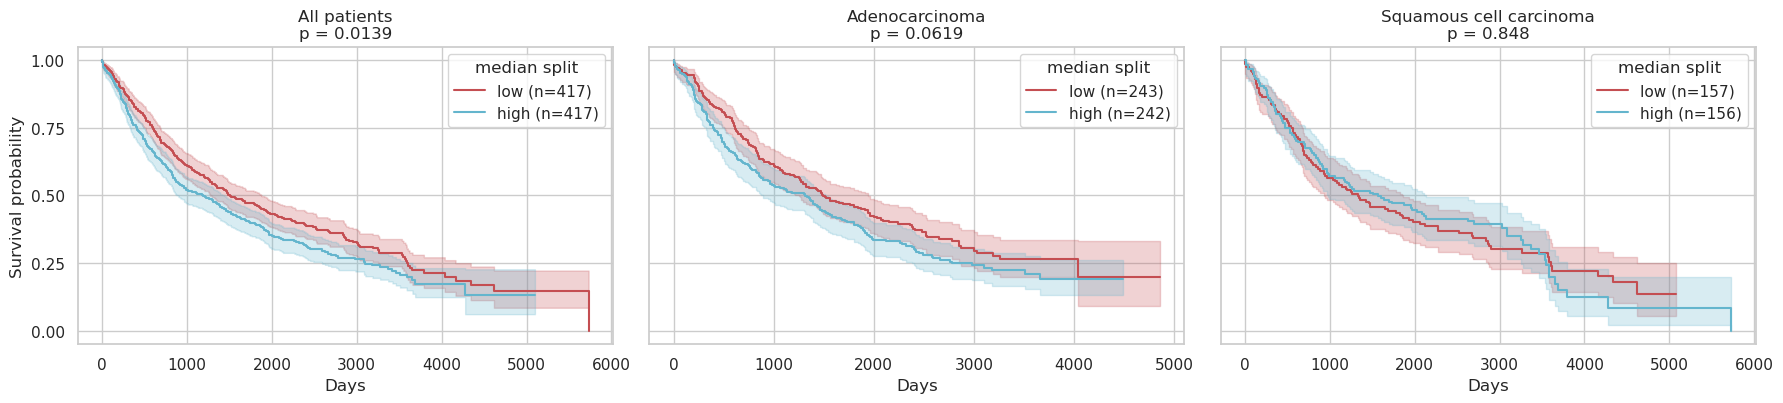

,cohort,tumor_type,feature,n,n_low,n_high,events_low,events_high,median_feature,pval_logrank,filter_reason
0,All patients,All,cell_category_tumor_to_cell_category_vessel,834,417,417,282.0,300.0,-0.634791,0.013865,tested
1,Adenocarcinoma,Adenocarcinoma,cell_category_tumor_to_cell_category_vessel,485,243,242,158.0,177.0,-0.595048,0.061880,tested
2,Squamous cell carcinoma,Squamous cell carcinoma,cell_category_tumor_to_cell_category_vessel,313,157,156,110.0,106.0,-0.724540,0.847925,tested


In [14]:
if results_df.empty:
    raise RuntimeError("No features passed the survival screen eligibility filters.")

best_col = results_df.sort_values("pval").iloc[0]["feature"]
print(f"Plotting KM curves for: {best_col}")

def plot_km_by_feature(ax, data, feature, title, tumor_type=None):
    km_cols = [feature, "OS", "Ev.O", "Patient_ID", "DX.name"]
    km_df = data[km_cols].copy()
    if tumor_type is not None:
        km_df = km_df.loc[km_df["DX.name"] == tumor_type].copy()
    km_df = km_df.dropna(subset=[feature, "OS", "Ev.O"]).copy()
    if km_df.shape[0] < MINIMUM_GROUP_SIZE * 2:
        ax.set_title(f"{title}\ninsufficient patients")
        ax.axis("off")
        return {"cohort": title, "feature": feature, "n": km_df.shape[0], "pval_logrank": np.nan, "filter_reason": "n_available"}

    median_feature = km_df[feature].median()
    km_df["exp_group"] = np.where(km_df[feature] > median_feature, "high", "low")
    low_df = km_df.loc[km_df["exp_group"] == "low"]
    high_df = km_df.loc[km_df["exp_group"] == "high"]

    if min(low_df.shape[0], high_df.shape[0]) < MINIMUM_GROUP_SIZE:
        ax.set_title(f"{title}\ninsufficient group size")
        ax.axis("off")
        return {"cohort": title, "feature": feature, "n": km_df.shape[0], "pval_logrank": np.nan, "filter_reason": "n_per_group"}

    logrank_res = logrank_test(
        low_df["OS"], high_df["OS"],
        event_observed_A=low_df["Ev.O"],
        event_observed_B=high_df["Ev.O"],
    )

    kmf = KaplanMeierFitter()
    colors = {"low": sns.color_palette("deep")[3], "high": sns.color_palette("deep")[9]}
    for group, group_df in [("low", low_df), ("high", high_df)]:
        kmf.fit(group_df["OS"], event_observed=group_df["Ev.O"], label=f"{group} (n={group_df.shape[0]})")
        kmf.plot(ax=ax, c=colors[group])

    ax.set_title(f"{title}\np = {logrank_res.p_value:.3g}")
    ax.set_xlabel("Days")
    ax.set_ylabel("Survival probability")
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.legend(title="median split")
    return {
        "cohort": title,
        "tumor_type": tumor_type if tumor_type is not None else "All",
        "feature": feature,
        "n": km_df.shape[0],
        "n_low": low_df.shape[0],
        "n_high": high_df.shape[0],
        "events_low": low_df["Ev.O"].sum(),
        "events_high": high_df["Ev.O"].sum(),
        "median_feature": median_feature,
        "pval_logrank": logrank_res.p_value,
        "filter_reason": "tested",
    }

km_cohorts = [
    ("All patients", None),
    ("Adenocarcinoma", "Adenocarcinoma"),
    ("Squamous cell carcinoma", "Squamous cell carcinoma"),
]
fig, axes = plt.subplots(1, len(km_cohorts), figsize=(6 * len(km_cohorts), 4.2), sharey=True)
km_results = []
for ax, (title, tumor_type) in zip(axes, km_cohorts):
    km_results.append(plot_km_by_feature(ax, survival_df, best_col, title, tumor_type))

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cell_category_figure6c_top_feature_km.pdf", bbox_inches="tight")
plt.show()

km_results_df = pd.DataFrame(km_results)
km_results_df.to_csv(OUTPUT_DIR / "cell_category_figure6c_top_feature_km_results.csv", index=False)
display(km_results_df)

# codex-human diff check

In [15]:
codex_mapping = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-08-26_results/cell_categories_accuml_sum.csv')
manual_mapping = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nontumor_cell_subtypes_accuml_sum.csv')

In [32]:
codex_mapping_nontumor = codex_mapping[codex_mapping['cell_category']!='tumor']
codex_classified = codex_mapping_nontumor[~codex_mapping_nontumor['final_cell_type'].isna()]
# codex_classified
np.unique(codex_classified['cell_category'], return_counts=True)
np.unique(codex_classified['final_cell_type'], return_counts=True)

(array(['B cells', 'CD4', 'CD4 Treg', 'CD8', 'Collagen CAF', 'IDO_CD4',
        'IDO_CD8', 'IFN CAF', 'Ki67_CD4', 'Ki67_CD8', 'PD1 CD4',
        'PDPN CAF', 'SMA CAF', 'TCF1/7 CD4', 'TCF1/7 CD8', 'dCAF',
        'endothelial', 'high endothelial venules (HEV)', 'hypoxic CAF',
        'hypoxic tCAF', 'iCAF', 'lymphatic endothelial', 'mCAF', 'myeloid',
        'neutrophils', 'tCAF', 'vCAF'], dtype=object),
 array([ 72278,    872,   2256,  25686, 143197,    305,   1598,  32185,
           572,   2562,     55,  29612, 156004,     89,    681,  62842,
         35700,    186,  63020,   9006,  11466,   2949,  12860,  60147,
         31012,   6981,  31862]))

In [28]:
manual_classified = manual_mapping[~manual_mapping['final_cell_type'].isna()]
np.unique(manual_classified['final_cell_type'], return_counts=True)

(array(['B cells', 'CD4', 'CD4 Treg', 'CD8', 'Collagen CAF', 'IDO_CD4',
        'IDO_CD8', 'IFN CAF', 'Ki67_CD4', 'Ki67_CD8', 'PD1 CD4',
        'PDPN CAF', 'SMA CAF', 'TCF1/7 CD4', 'TCF1/7 CD8', 'dCAF',
        'endothelial', 'high endothelial venules (HEV)', 'hypoxic CAF',
        'hypoxic tCAF', 'iCAF', 'lymphatic endothelial', 'mCAF', 'myeloid',
        'neutrophils', 'tCAF', 'vCAF'], dtype=object),
 array([ 72278,    872,   2256,  25686, 143197,    305,   1598,  32185,
           572,   2562,     55,  29612, 156004,     89,    681,  62842,
         35700,    186,  63020,   9006,  11466,   2949,  12860,  60147,
         31012,   6981,  31862]))